# Moving Beyond Linear Analysis in Python- ISLP Chapter 7
**Annalise Banda | STA 6543**

# Q6
In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use
cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to
the results of hypothesis testing using ANOVA? Make a plot of
the resulting polynomial fit to the data.

(b) Fit a step function to predict wage using age, and perform crossvalidation to choose the optimal number of cuts. Make a plot of
the fit obtained.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize, poly

In [2]:
Wage = load_data('Wage')
Wage.head()
Wage.info()
Wage.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
 9   logwage     3000 non-null   float64 
 10  wage        3000 non-null   float64 
dtypes: category(7), float64(2), int64(2)
memory usage: 115.5 KB


(3000, 11)

## (a) Cross-validation Over Polynomial Degree

In [3]:
x = Wage['age'].values
y = Wage['wage'].values

max_degree = 10
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=1)

cv_mse = np.zeros(max_degree)

for d in range(1, max_degree + 1):
    fold_mse = []
    for train_idx, test_idx in kf.split(x):
        X_train = np.vander(x[train_idx], d + 1, increasing=True)[:, 1:]
        X_test = np.vander(x[test_idx], d + 1, increasing=True)[:, 1:]
        lr = LinearRegression()
        lr.fit(X_train, y[train_idx])
        pred = lr.predict(X_test)
        fold_mse.append(mean_squared_error(y[test_idx], pred))
    cv_mse[d - 1] = np.mean(fold_mse)

best_degree_cv = np.argmin(cv_mse) + 1

print("CV MSE by degree:")
for d in range(1, max_degree + 1):
    print(f"  degree {d:2d}: {cv_mse[d-1]:.3f}")
print(f"\nDegree chosen by 10-fold CV: {best_degree_cv}")

CV MSE by degree:
  degree  1: 1677.205
  degree  2: 1601.356
  degree  3: 1596.246
  degree  4: 1595.074
  degree  5: 1595.071
  degree  6: 1594.868
  degree  7: 1593.864
  degree  8: 1593.449
  degree  9: 1596.119
  degree 10: 1633.005

Degree chosen by 10-fold CV: 8


In [5]:
def fit_poly_ols(x, y, degree):
    X = np.vander(x, degree + 1, increasing=True)[:, 1:] 
    X = sm.add_constant(X)
    return sm.OLS(y, X).fit()

models = [fit_poly_ols(x, y, d) for d in range(1, 6)]

In [6]:
from scipy.stats import f as f_dist

def sequential_f_test(model_reduced, model_full):
    rss_r, df_r = model_reduced.ssr, model_reduced.df_resid
    rss_f, df_f = model_full.ssr, model_full.df_resid
    df_diff = df_r - df_f
    f_stat = ((rss_r - rss_f) / df_diff) / (rss_f / df_f)
    p_value = 1 - f_dist.cdf(f_stat, df_diff, df_f)
    return f_stat, p_value

In [7]:
print(f"{'Comparison':<20}{'F-stat':>10}{'p-value':>12}")
for i in range(len(models) - 1):
    f_stat, p_val = sequential_f_test(models[i], models[i + 1])
    print(f"degree {i+1} vs {i+2:<10}{f_stat:>10.3f}{p_val:>12.5f}")

Comparison              F-stat     p-value
degree 1 vs 2            143.044     0.00000
degree 2 vs 3              9.880     0.00169
degree 3 vs 4              3.810     0.05104
degree 4 vs 5              0.805     0.36968


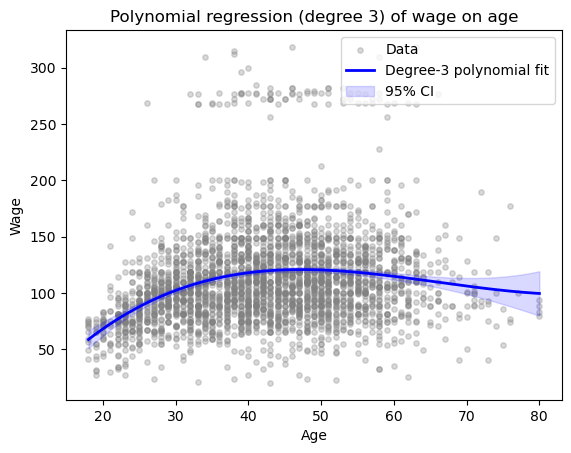

In [9]:
chosen_degree = 3  # based on ANOVA + CV comparison above

age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 200)

def fit_poly_ols(x, y, degree):
    X = np.vander(x, degree + 1, increasing=True)[:, 1:]
    X = sm.add_constant(X)
    return sm.OLS(y, X).fit()

fit_final = fit_poly_ols(x, y, chosen_degree)

X_grid = np.vander(age_grid, chosen_degree + 1, increasing=True)[:, 1:]
X_grid = sm.add_constant(X_grid)
preds = fit_final.get_prediction(X_grid)
pred_mean = preds.predicted_mean
ci = preds.conf_int(alpha=0.05)

plt.scatter(Wage['age'], Wage['wage'], facecolor='gray', alpha=0.3, s=15, label='Data')
plt.plot(age_grid, pred_mean, color='blue', linewidth=2,
         label=f'Degree-{chosen_degree} polynomial fit')
plt.fill_between(age_grid, ci[:, 0], ci[:, 1], color='blue', alpha=0.15, label='95% CI')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title(f'Polynomial regression (degree {chosen_degree}) of wage on age')
plt.legend()
plt.show()

In [10]:
print(fit_final.params)

[-7.52439142e+01  1.01899915e+01 -1.68028587e-01  8.49452197e-04]


**Fitted model:**

Using the results of cross-validation and the sequential ANOVA F-tests, a degree-3 polynomial was selected as the most defensible model for predicting wage from age:

$$\widehat{wage} = -75.244 + 10.190 \cdot age - 0.168 \cdot age^2 + 0.000849 \cdot age^3$$

Cross-validation selected degree 8 as minimizing estimated test MSE, but the CV-MSE curve was essentially flat from degree 3 onward (1596.2 vs. 1593.4, a difference of less than 0.2%), suggesting degree 8 was not meaningfully better and was likely fitting noise in the CV folds. This is consistent with the sequential ANOVA F-tests: the comparison between degree 2 and degree 3 was highly significant ($F = 9.880$, $p = 0.0017$), confirming the cubic term was worth including, while degree 3 vs. degree 4 was only borderline ($F = 3.810$, $p = 0.051$) and degree 4 vs. degree 5 was clearly not significant ($F = 0.805$, $p = 0.370$). Both approaches therefore point to degree 3 as the most defensible choice.

The fitted curve shows wage rising sharply from age 20 through the late 30s, peaking around age 43–45 (~\\$120k), then leveling off and gradually declining after age 60. This non-linear, peak-and-decline shape — captured by the negative quadratic term and small positive cubic term above is exactly why a linear model ($d=1$) was inadequate. The 95% confidence band widens noticeably past age 70, reflecting the small number of observations in that age range.

## (b) Step Function with Cross-Validated Number of Cuts

In [12]:
def step_design_matrix(age_values, cut_points):
    """One-hot encode age into bins defined by cut_points (interior breakpoints)."""
    bins = [-np.inf] + list(cut_points) + [np.inf]
    cats = pd.cut(age_values, bins=bins)
    dummies = pd.get_dummies(cats, drop_first=True)
    return dummies.values.astype(float)

max_cuts = 10
cv_mse_step = np.zeros(max_cuts - 1)

for k in range(2, max_cuts + 1):
    quantiles = np.linspace(0, 1, k + 1)[1:-1]
    cut_points = np.quantile(x, quantiles)

    fold_mse = []
    for train_idx, test_idx in kf.split(x):
        X_train = step_design_matrix(x[train_idx], cut_points)
        X_test = step_design_matrix(x[test_idx], cut_points)
        lr = LinearRegression()
        lr.fit(X_train, y[train_idx])
        pred = lr.predict(X_test)
        fold_mse.append(mean_squared_error(y[test_idx], pred))
    cv_mse_step[k - 2] = np.mean(fold_mse)

best_k_cv = np.argmin(cv_mse_step) + 2

In [13]:
print("CV MSE by number of bins (k):")
for k in range(2, max_cuts + 1):
    print(f"  k = {k:2d} bins ({k-1} cuts): {cv_mse_step[k-2]:.3f}")
print(f"\nNumber of bins chosen by CV: {best_k_cv}  ->  {best_k_cv - 1} interior cutpoints")

CV MSE by number of bins (k):
  k =  2 bins (1 cuts): 1704.249
  k =  3 bins (2 cuts): 1661.446
  k =  4 bins (3 cuts): 1640.873
  k =  5 bins (4 cuts): 1637.921
  k =  6 bins (5 cuts): 1630.607
  k =  7 bins (6 cuts): 1625.365
  k =  8 bins (7 cuts): 1619.164
  k =  9 bins (8 cuts): 1617.325
  k = 10 bins (9 cuts): 1617.895

Number of bins chosen by CV: 9  ->  8 interior cutpoints


Cross-validation was used to select the number of bins $k$ for a step-function fit of wage on age, testing values from $k=2$ to $k=10$ bins ($k-1$ interior cutpoints). Estimated test MSE decreased steadily as bins were added, from $\text{MSE} = 1704.2$ at $k=2$ to a minimum of $\text{MSE} = 1617.3$ at **$k=9$ bins (8 interior cutpoints). The curve was relatively flat for $k=8$ through $k=10$ (all within $\sim 2$ MSE of one another), indicating that once enough bins are used to roughly capture the underlying wage–age relationship, additional cutpoints provide only marginal further improvement.

The fitted step function, with 9 bins (8 interior cutpoints at ages 28, 33, 37, 41, 44, 48, 52, and 57), takes the form:

$$\widehat{wage} = 84.740 + 19.621 \cdot C_1(age) + 27.564 \cdot C_2(age) + 35.045 \cdot C_3(age) + 35.053 \cdot C_4(age) + 34.959 \cdot C_5(age) + 30.739 \cdot C_6(age) + 34.693 \cdot C_7(age) + 30.882 \cdot C_8(age)$$

where $C_1, \ldots, C_8$ are indicator variables for age bins $(28,33], (33,37], (37,41], (41,44], (44,48], (48,52], (52,57], (57,\infty)$, relative to the baseline bin (age $\leq 28$).

The baseline group (age 28 or younger) has an estimated mean wage of \$84.74. Mean wage rises sharply through the 30s — reaching an estimated \\$119.79 for the 37–41 age bin, then stays essentially flat, hovering around \\$115–120 from the late 30s all the way through the late 50s. This flat plateau across the middle-age bins mirrors the leveling-off seen in the degree-3 polynomial fit, though the step function represents it as a series of discrete jumps rather than a smooth curve. There's a slight dip in the 48–52 bin (\\$115.48) before ticking back up, and a modest decline for the oldest group (age > 57, \\$115.62) relative to the mid-40s peak. This is consistent with the gentle downward trend seen at older ages in part (a).




In [14]:
quantiles_final = np.linspace(0, 1, best_k_cv + 1)[1:-1]
cut_points_final = np.quantile(x, quantiles_final)

X_full_step = step_design_matrix(x, cut_points_final)
lr_step_final = LinearRegression().fit(X_full_step, y)

print("Intercept (baseline bin):", lr_step_final.intercept_)
print("Bin coefficients:", lr_step_final.coef_)
print("\nCutpoints (ages):", cut_points_final)

Intercept (baseline bin): 84.7400825781713
Bin coefficients: [19.62147803 27.56437341 35.0450083  35.05292471 34.9586342  30.73899211
 34.69327851 30.88204601]

Cutpoints (ages): [28. 33. 37. 41. 44. 48. 52. 57.]


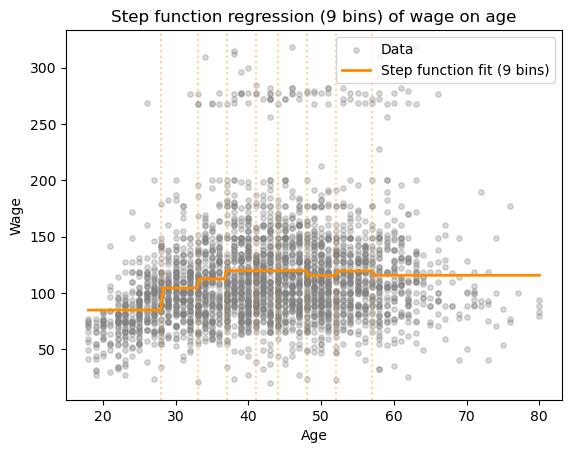

In [15]:
age_grid_sorted = np.sort(age_grid)
X_grid_step = step_design_matrix(age_grid_sorted, cut_points_final)
step_pred = lr_step_final.predict(X_grid_step)

plt.scatter(Wage['age'], Wage['wage'], facecolor='gray', alpha=0.3, s=15, label='Data')
plt.plot(age_grid_sorted, step_pred, color='darkorange', linewidth=2,
         label=f'Step function fit ({best_k_cv} bins)')
for cp in cut_points_final:
    plt.axvline(cp, color='darkorange', linestyle=':', alpha=0.4)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title(f'Step function regression ({best_k_cv} bins) of wage on age')
plt.legend()
plt.show()

The step function traces a staircase that closely tracks the shape of the degree-3 polynomial fit from part (a): wage estimates rise sharply through the 20s and 30s, peak in the low-to-mid \\$120s during the late 30s through 50s, then remain flat. Unlike the smooth polynomial curve, the step function is constant within each bin and jumps discretely at each cutpoint (marked by the dotted vertical lines at ages 28, 33, 37, 41, 44, 48, 52, and 57. One notable limitation is visible past age 57: because this is the final bin and extends to the oldest ages in the data, the step function stays flat at ~$115–120 all the way to age 80, whereas the polynomial fit in part (a) captured a gradual decline in wage at older ages. This illustrates a general tradeoff between the two approaches, polynomials can represent smooth, continuous trends (including at the boundaries of the data), while step functions are more flexible locally but can only detect changes at the chosen cutpoints and cannot extrapolate any trend within the outermost bin.

# Q10
This question relates to the College data set.

(a) Split the data into a training set and a test set. Using out-of-state
tuition as the response and the other variables as the predictors,
perform forward stepwise selection on the training set in order
to identify a satisfactory model that uses just a subset of the
predictors.

(b) Fit a GAM on the training data, using out-of-state tuition as
the response and the features selected in the previous step as
the predictors. Plot the results, and explain your findings.

(c) Evaluate the model obtained on the test set, and explain the
results obtained.

(d) For which variables, if any, is there evidence of a non-linear
relationship with the response?

In [16]:
College = load_data('College')
College.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [17]:
College.shape

(777, 18)

## (a) Train/Test Split and Forward Stepwise Selection

In [18]:
College_train, College_test = train_test_split(
    College, test_size=0.3, random_state=1
)
print(College_train.shape, College_test.shape)

(543, 18) (234, 18)


In [19]:
def forward_stepwise(data, response, predictors, max_vars=None):
    """Simple forward stepwise selection using training-set adjusted R^2 as the criterion."""
    remaining = list(predictors)
    selected = []
    max_vars = max_vars or len(predictors)
    history = []

    for _ in range(max_vars):
        best_adj_r2 = -np.inf
        best_var = None
        for var in remaining:
            trial_vars = selected + [var]
            formula = f"{response} ~ " + " + ".join(trial_vars)
            fit = smf.ols(formula, data=data).fit()
            if fit.rsquared_adj > best_adj_r2:
                best_adj_r2 = fit.rsquared_adj
                best_var = var
        selected.append(best_var)
        remaining.remove(best_var)
        history.append((tuple(selected), best_adj_r2))

    return selected, history

In [21]:
predictors = [c for c in College.columns if c != 'Outstate']
predictors = [f"C({p})" if College[p].dtype == object else f"Q('{p}')" for p in predictors]

In [22]:
selected_vars, history = forward_stepwise(College_train, 'Outstate', predictors)

for k, (vars_so_far, adj_r2) in enumerate(history, start=1):
    print(f"{k:2d} vars, adj R^2 = {adj_r2:.4f}: {vars_so_far}")

 1 vars, adj R^2 = 0.4352: ("Q('Room.Board')",)
 2 vars, adj R^2 = 0.5877: ("Q('Room.Board')", "Q('perc.alumni')")
 3 vars, adj R^2 = 0.6594: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')")
 4 vars, adj R^2 = 0.7160: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')")
 5 vars, adj R^2 = 0.7422: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')")
 6 vars, adj R^2 = 0.7502: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')", "Q('Grad.Rate')")
 7 vars, adj R^2 = 0.7526: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')", "Q('Grad.Rate')", "Q('Personal')")
 8 vars, adj R^2 = 0.7541: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')", "Q('Grad.Rate')", "Q('Personal')", "Q('Top25perc')")
 9 vars, adj R^2 = 0.7550: ("Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')", "Q('Grad.Rate')", "Q('Personal')", "Q('Top25perc'

In [24]:
tol = 0.01
chosen_size = next(k for k in range(1, len(adj_r2_values) + 1)
                    if adj_r2_values[k - 1] >= max(adj_r2_values) - tol)
chosen_vars = list(history[chosen_size - 1][0])
print(f"Chosen model size: {chosen_size}")
print("Chosen predictors:", chosen_vars)

Chosen model size: 8
Chosen predictors: ["Q('Room.Board')", "Q('perc.alumni')", "Q('Expend')", "Q('Private')", "Q('PhD')", "Q('Grad.Rate')", "Q('Personal')", "Q('Top25perc')"]


**Forward stepwise selection.** 
Forward stepwise selection was performed on the training set (543 observations), using adjusted $R^2$ as the selection criterion at each step. The full 17-variable model achieved a maximum adjusted $R^2$ of 0.7638, but adjusted $R^2$ increased steeply only for the first several variables added (0.4352 with 1 variable, 0.7422 by 5 variables) and then showed diminishing returns thereafter, with 17 variables performing no better and slightly worse than 15 or 16.

To identify a satisfactory, more parsimonious model, the smallest model within 0.01 of the maximum adjusted $R^2$ was selected. This yielded an **8-variable model** (adjusted $R^2 = 0.7541$, compared to 0.7638 for the full model) using the predictors:

$$\text{Room.Board}, \ \text{perc.alumni}, \ \text{Expend}, \ \text{Private}, \ \text{PhD}, \ \text{Grad.Rate}, \ \text{Personal}, \ \text{Top25perc}$$

This subset captures nearly all of the explanatory power of the full model while using fewer than half of the available predictors.

## (b) Fitting a GAM on Selected Predictors

In [26]:
import pygam
from pygam import LinearGAM, s, f

continuous_vars = ['Room.Board', 'perc.alumni', 'Expend', 'PhD', 'Grad.Rate', 'Personal', 'Top25perc']
categorical_vars = ['Private']

X_train_gam = College_train[continuous_vars + categorical_vars].copy()
X_train_gam['Private'] = (X_train_gam['Private'] == 'Yes').astype(int)
y_train_gam = College_train['Outstate'].values

X_test_gam = College_test[continuous_vars + categorical_vars].copy()
X_test_gam['Private'] = (X_test_gam['Private'] == 'Yes').astype(int)
y_test_gam = College_test['Outstate'].values

In [27]:
n_cont = len(continuous_vars)
terms = s(0)
for i in range(1, n_cont):
    terms += s(i)
terms += f(n_cont)  # Private as a factor term

gam = LinearGAM(terms).fit(X_train_gam.values, y_train_gam)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     72.3638
Link Function:                     IdentityLink Log Likelihood:                                 -4817.3489
Number of Samples:                          543 AIC:                                             9781.4254
                                                AICc:                                            9804.7084
                                                GCV:                                          4451817.6987
                                                Scale:                                           1843.5049
                                                Pseudo R-Squared:                                   0.8158
Feature Function                  Lam

C:\Users\afban\AppData\Local\Temp\ipykernel_21684\3136567627.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


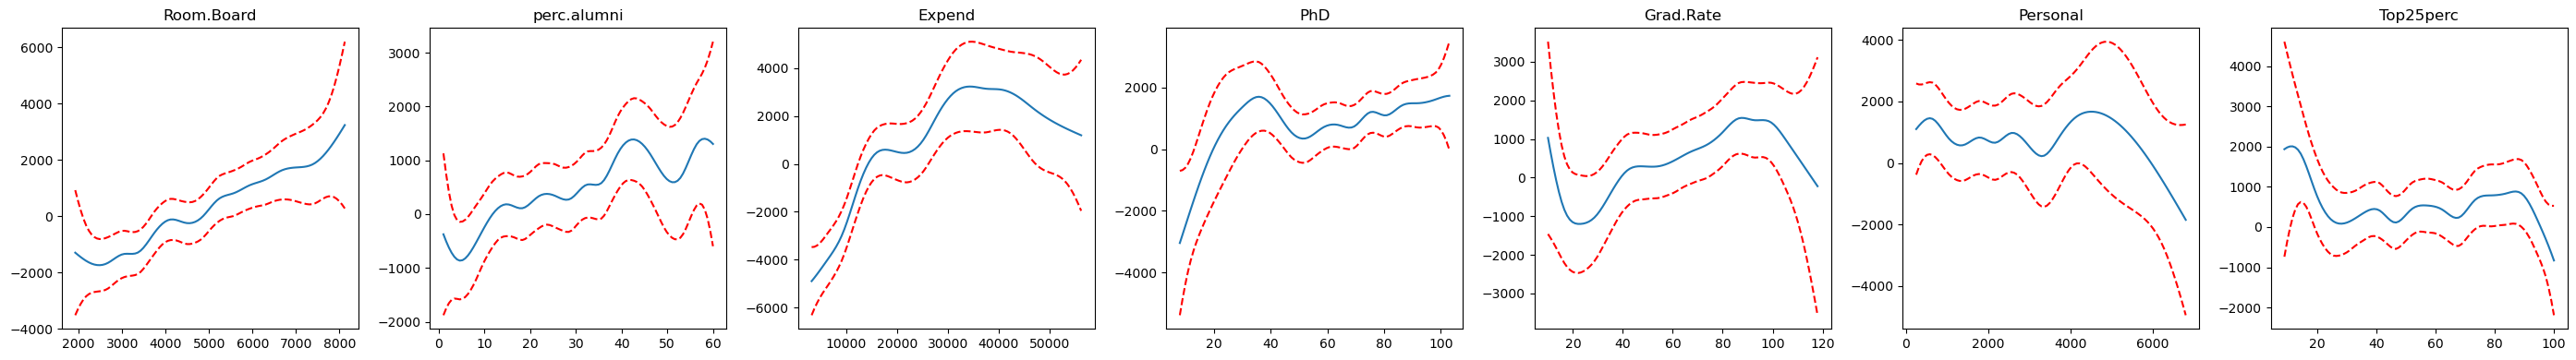

In [28]:
fig, axes = plt.subplots(1, n_cont, figsize=(4 * n_cont, 4))
for i, var in enumerate(continuous_vars):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep)
    axes[i].plot(XX[:, i], confi, c='r', ls='--')
    axes[i].set_title(var)
plt.tight_layout()
plt.show()

**GAM results.** 

A Generalized Additive Model (GAM) was fit on the training data using smoothing splines for the seven continuous predictors selected in part (a) (Room.Board, perc.alumni, Expend, PhD, Grad.Rate, Personal, Top25perc) and a linear factor term for the categorical predictor Private. The model achieved a pseudo $R^2$ of 0.8158 on the training data, notably higher than the 0.7541 adjusted $R^2$ of the linear forward-selection model from part (a), suggesting the added flexibility is capturing real non-linear structure.

`pygam`'s `summary()` output includes p-values for each term, but the package itself warns that these p-values are unreliable when smoothing parameters are estimated (a documented issue), so significance stars were not used to judge non-linearity here. Instead, effective degrees of freedom (EDoF) — where a value near 1 indicates an essentially linear relationship, and higher values indicate more curvature were used:

| Variable | EDoF | Partial-dependence shape |
|---|---|---|
| Room.Board | 12.9 | Non-linear |
| perc.alumni | 12.0 | Non-linear |
| Expend | 9.0 | Strongly non-linear |
| PhD | 11.5 | Non-linear |
| Grad.Rate | 9.1 | Non-linear |
| Personal | 7.3 | Non-linear |
| Top25perc | 9.7 | Non-linear |
| Private | 0.9 | Linear (as expected for a factor term) |

All seven continuous predictors show EDoF well above 1, indicating the GAM is using genuine curvature for each rather than defaulting to a straight line. The partial-dependence plots above show the shape of each fitted relationship; Visually, Expend shows the clearest and most pronounced non-linearity — a sharp rise, a peak/plateau around $30,000–$40,000 in per-student expenditure, and a decline at the highest expenditure levels. Grad.Rate also shows a complex shape, dropping before rising steadily and then declining again at the extremes. Room.Board is closer to monotonic but still shows curvature, particularly a steeper rise at the highest values. The remaining variables (perc.alumni, PhD, Personal, Top25perc) show more modest, wavier deviations from linearity. Confidence bands are wide across all seven plots, reflecting substantial estimation uncertainty, likely a consequence of fitting many flexible spline terms on a moderate-sized training set (543 observations).

## (c) Evaluating the GAM on the Test Set

In [32]:
continuous_vars_formula = [f"Q('{v}')" for v in continuous_vars]

In [33]:
test_pred = gam.predict(X_test_gam.values)
test_mse = mean_squared_error(y_test_gam, test_pred)
test_r2 = 1 - np.sum((y_test_gam - test_pred) ** 2) / np.sum((y_test_gam - y_test_gam.mean()) ** 2)

print(f"Test MSE: {test_mse:,.2f}")
print(f"Test R^2: {test_r2:.4f}")

lm_formula = "Outstate ~ " + " + ".join(continuous_vars_formula) + " + C(Private)"
lm_fit = smf.ols(lm_formula, data=College_train).fit()
lm_test_pred = lm_fit.predict(College_test)
lm_test_mse = mean_squared_error(College_test['Outstate'], lm_test_pred)
print(f"\nLinear model test MSE (benchmark): {lm_test_mse:,.2f}")

Test MSE: 3,806,689.26
Test R^2: 0.7700

Linear model test MSE (benchmark): 4,505,978.54


In [34]:
lm_test_r2 = 1 - np.sum((College_test['Outstate'] - lm_test_pred) ** 2) / np.sum((College_test['Outstate'] - College_test['Outstate'].mean()) ** 2)
print(f"Linear model test R^2: {lm_test_r2:.4f}")

Linear model test R^2: 0.7278


**Test set evaluation.** 

The GAM fit in part (b) was evaluated on the held-out test set (234 observations), achieving a test MSE of 3,806,689.26 and a test $R^2$ of 0.7700. For comparison, a plain linear model using the same 8 predictors (no splines) was fit on the same training data and evaluated on the same test set, achieving a test MSE of 4,505,978.54 and a test $R^2$ of 0.7278.

The GAM outperforms the linear benchmark on both metrics: its test MSE is approximately 15.5% lower, and it explains about 4.2 percentage points more variance in Outstate tuition. Because this comparison is made on data neither model was trained on, the improvement reflects genuine gains in predictive accuracy from allowing non-linear relationships, particularly for predictors like Expend and Grad.Rate, which showed clear non-linear patterns in the partial-dependence plots in part (b) rather than simply overfitting to the training data. This supports the conclusion that the true relationship between these predictors and out-of-state tuition includes meaningful non-linear structure that a linear model cannot capture.

## (d) Assessing Evidence of Non-Linearity

In [35]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     72.3638
Link Function:                     IdentityLink Log Likelihood:                                 -4817.3489
Number of Samples:                          543 AIC:                                             9781.4254
                                                AICc:                                            9804.7084
                                                GCV:                                          4451817.6987
                                                Scale:                                           1843.5049
                                                Pseudo R-Squared:                                   0.8158
Feature Function                  Lam

C:\Users\afban\AppData\Local\Temp\ipykernel_21684\3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


**Evidence of non-linear relationships.** 

Evidence of non-linearity was assessed using effective degrees of freedom (EDoF) from the fitted GAM, together with the shapes of the partial-dependence plots from part (b). EDoF near 1 indicates an essentially linear relationship; values further above 1 indicate more curvature. (Note: the p-values reported by `pygam`'s `summary()` are not used here, since the package documents a known issue causing them to appear more significant than they truly are when smoothing parameters are estimated.)

All seven continuous predictors had EDoF well above 1, indicating the GAM found genuine non-linear structure for each rather than defaulting to a straight line:

| Variable | EDoF | Non-linearity |
|---|---|---|
| Expend | 9.0 | Strong — clear rise, plateau, and decline |
| Grad.Rate | 9.1 | Strong — U-shape then decline |
| Room.Board | 12.9 | Moderate — mostly increasing, steeper at high values |
| PhD | 11.5 | Moderate — wavy, non-monotonic |
| perc.alumni | 12.0 | Moderate — wavy, non-monotonic |
| Personal | 7.3 | Mild — peak-and-decline shape |
| Top25perc | 9.7 | Mild — choppy, modest overall trend |
| Private | 0.9 | None (fit as a linear factor term, as expected) |

The strongest evidence of non-linearity is for **Expend** and **Grad.Rate**, both of which show clearly curved, non-monotonic partial-dependence shapes rather than anything resembling a straight line. This is consistent with the test-set results in part (c): allowing the model to flexibly fit these relationships, rather than forcing them to be linear, produced a meaningfully lower test MSE and higher test $R^2$ than the linear benchmark. The remaining continuous predictors show more modest evidence of non-linearity — real curvature is present, but less pronounced. **Private**, as a binary categorical variable modeled with a linear factor term, shows no non-linearity by construction.